Housing Prices Competition

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('home-data-for-ml-course/train.csv')

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df['SalePrice'] = np.log1p(df['SalePrice'])
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,12.247699
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,12.109016
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,12.317171
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,12.429220


In [6]:
df.drop(columns=['Id'], inplace=True)
limitPer = len(df) * .80
df = df.dropna(thresh=limitPer, axis=1)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
variance = np.var(df[numeric_cols], axis=0)

In [8]:
low_variance_cols = variance[variance <0.01].index
df.drop(columns = low_variance_cols, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [9]:
missing_values = df.isnull().sum()
df.drop(columns=missing_values[missing_values > 0.5].index, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 61 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotArea        1460 non-null   int64  
 3   Street         1460 non-null   object 
 4   LotShape       1460 non-null   object 
 5   LandContour    1460 non-null   object 
 6   Utilities      1460 non-null   object 
 7   LotConfig      1460 non-null   object 
 8   LandSlope      1460 non-null   object 
 9   Neighborhood   1460 non-null   object 
 10  Condition1     1460 non-null   object 
 11  Condition2     1460 non-null   object 
 12  BldgType       1460 non-null   object 
 13  HouseStyle     1460 non-null   object 
 14  OverallQual    1460 non-null   int64  
 15  OverallCond    1460 non-null   int64  
 16  YearBuilt      1460 non-null   int64  
 17  YearRemodAdd   1460 non-null   int64  
 18  RoofStyl

In [10]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation = numeric_df.corr()['SalePrice']

low_corr_cols = correlation[correlation.abs() < 0.1].index
# 2. Define "Protected" columns you want to keep no matter what
protected_cols = ['BsmtHalfBath', 'BsmtFullBath', 'HalfBath', 'FullBath']

# 3. Filter the drop list: remove protected columns from the list of columns to drop
cols_to_drop = [c for c in low_corr_cols if c not in protected_cols]

# 4. Drop only the unprotected ones
df.drop(columns=cols_to_drop, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 52 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1460 non-null   object 
 1   LotArea        1460 non-null   int64  
 2   Street         1460 non-null   object 
 3   LotShape       1460 non-null   object 
 4   LandContour    1460 non-null   object 
 5   Utilities      1460 non-null   object 
 6   LotConfig      1460 non-null   object 
 7   LandSlope      1460 non-null   object 
 8   Neighborhood   1460 non-null   object 
 9   Condition1     1460 non-null   object 
 10  Condition2     1460 non-null   object 
 11  BldgType       1460 non-null   object 
 12  HouseStyle     1460 non-null   object 
 13  OverallQual    1460 non-null   int64  
 14  YearBuilt      1460 non-null   int64  
 15  YearRemodAdd   1460 non-null   int64  
 16  RoofStyle      1460 non-null   object 
 17  RoofMatl       1460 non-null   object 
 18  Exterior

In [11]:
# Remove outliers as recommended by the author of the dataset
df = df.drop(df[(df['GrLivArea']>4000) & (df['SalePrice']<300000)].index)

In [12]:
# Total Square Footage
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# Total Bathrooms
df['TotalBath'] = (df['FullBath'] + (0.5 * df['HalfBath']) + 
                   df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))
cols_to_drop = ['1stFlrSF', '2ndFlrSF', 'TotalBsmtSF', 
                'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']
df.drop(columns=cols_to_drop, inplace=True)

In [13]:
from sklearn.model_selection import train_test_split

# Define features and target correctly
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [15]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 3. Create the scaler object
scaler = StandardScaler() 
# 4. Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [17]:
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0)
    }
    
    model = xgb.XGBRegressor(**params, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()
    return score
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best R2: {study.best_value}")
print(f"Best Params: {study.best_params}")


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-18 21:48:06,438] A new study created in memory with name: no-name-8b933269-9053-4c98-b7af-187a6fc268ef
[I 2026-03-18 21:48:06,902] Trial 0 finished with value: 0.8965234387204234 and parameters: {'n_estimators': 179, 'max_depth': 3, 'learning_rate': 0.1568248435020992, 'subsample': 0.90750166003862, 'colsample_bytree': 0.7948020917853853}. Best is trial 0 with value: 0.8965234387204234.
[I 2026-03-18 21:48:08,619] Trial 1 finished with value: 0.8861978034345814 and parameters: {'n_estimators': 809, 'max_depth': 7, 'learning_rate': 0.12782081406744347, 'subsample': 0.9522137499796246, 'colsample_bytree': 0.8231491072960744}. Best is trial 0 with value: 0.8965234387204234.
[I 2026-03-18 21:48:09,901] Trial 2 finish

Best R2: 0.9086556143949986
Best Params: {'n_estimators': 764, 'max_depth': 4, 'learning_rate': 0.03357410550814338, 'subsample': 0.50444052632274, 'colsample_bytree': 0.5542460943313653}


In [18]:
# 1. Initialize with Optuna's best params
final_model = xgb.XGBRegressor(
    n_estimators=787,
    max_depth=4,
    learning_rate=0.03541793617182125,
    subsample=0.7546999274141939,
    colsample_bytree=0.500765383186674,
    random_state=42
)

# 2. Fit on the full training data
final_model.fit(X_train, y_train)

# 3. Quick check on your local test split
final_preds = final_model.predict(X_test)
from sklearn.metrics import r2_score
print(f"Final Optimized R2: {r2_score(y_test, final_preds):.5f}")

Final Optimized R2: 0.89360


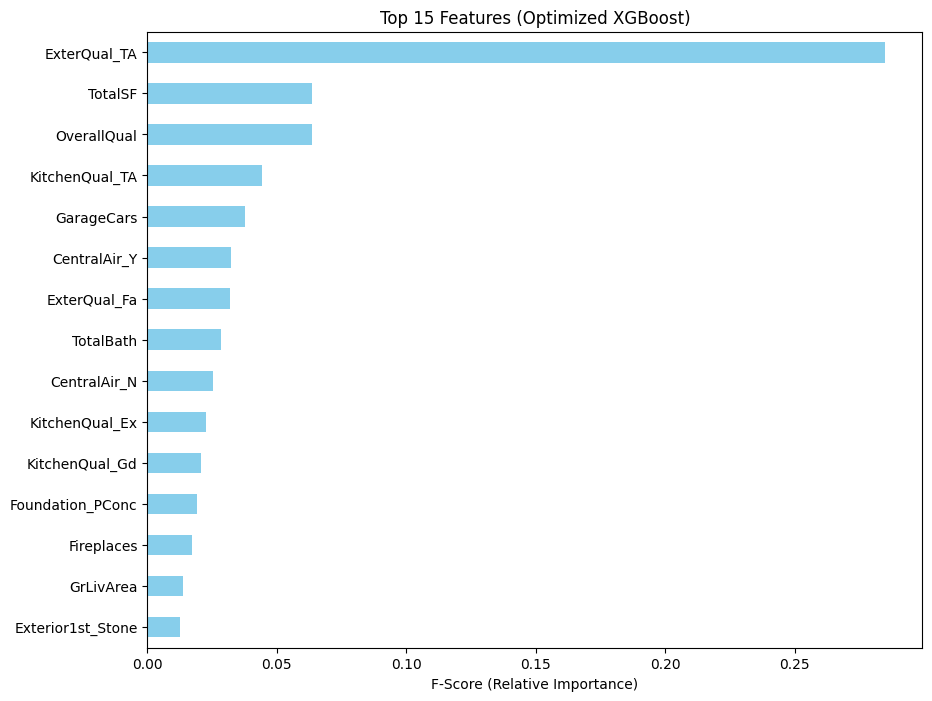

In [19]:
plt.figure(figsize=(10, 8))
# Get feature importances from the model
importances = pd.Series(final_model.feature_importances_, index=scaler.feature_names_in_)
# Plot the top 15
importances.nlargest(15).sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 15 Features (Optimized XGBoost)')
plt.xlabel('F-Score (Relative Importance)')
plt.show()

In [20]:
# loading the test data
test_df = pd.read_csv('home-data-for-ml-course/test.csv')

In [21]:
# 1. Load the test file
test_df = pd.read_csv('home-data-for-ml-course/test.csv')
test_ids = test_df['Id']

# 2. FEATURE ENGINEERING (Must happen before dropping columns)
# Fill NaNs in these specific columns with 0 so the math doesn't result in NaN
bsmt_cols = ['TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', '1stFlrSF', '2ndFlrSF', 'FullBath', 'HalfBath']
test_df[bsmt_cols] = test_df[bsmt_cols].fillna(0)

test_df['TotalSF'] = test_df['1stFlrSF'] + test_df['2ndFlrSF'] + test_df['TotalBsmtSF']
test_df['TotalBath'] = (test_df['FullBath'] + (0.5 * test_df['HalfBath']) + 
                        test_df['BsmtFullBath'] + (0.5 * test_df['BsmtHalfBath']))

# 3. DROP the ID and prepare for Dummies
test_features = test_df.drop('Id', axis=1)

# 4. ONE-HOT ENCODING
test_features = pd.get_dummies(test_features)

# 5. ALIGNMENT (The "Safety Net")
# This ensures test_features has EXACTLY the same columns in the same order
# as the data the scaler and model were trained on.
test_features = test_features.reindex(columns=scaler.feature_names_in_, fill_value=0)

# 6. SCALING
# We use the scaler that was already fitted on our training data
test_features_scaled = scaler.transform(test_features)

# 7. PREDICTION
# Remember we are predicting LOG price
test_preds_log = final_model.predict(test_features_scaled)

# 8. INVERT LOG
# We use np.expm1 to turn the log back into actual dollars
final_sale_prices = np.expm1(test_preds_log)

# 9. CREATE SUBMISSION
submission = pd.DataFrame({
    'Id': test_ids, 
    'SalePrice': final_sale_prices
})

submission.to_csv('submission.csv', index=False)
print("Submission file saved! Top 5 rows:")
print(submission.head())

Submission file saved! Top 5 rows:
     Id      SalePrice
0  1461  125039.382812
1  1462  160825.890625
2  1463  183211.078125
3  1464  186857.921875
4  1465  184533.765625
